In [33]:
import pandas as pd 
import numpy as np
import datetime         #Shows in my time zone COL.

8B51423J
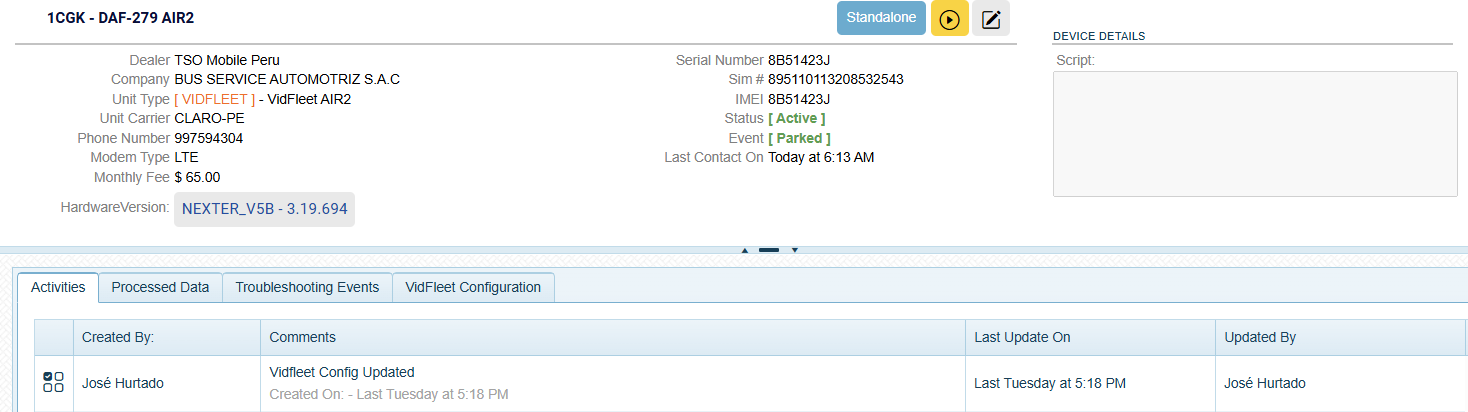

In [34]:
#vf=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sedisa\vck379.csv',sep=',')
#vf.info()

In [35]:
#11-08-2026 -> 13_08_2026
vf=pd.read_excel(r'C:\Users\jlhb1\OneDrive\Documentos\Zonar_projects\data\bus_service\daf279 AIR2.xlsx')
vf.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 92 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Message      107 non-null    str    
 1   Unnamed: 1   107 non-null    str    
 2   Unnamed: 2   107 non-null    str    
 3   Unnamed: 3   107 non-null    str    
 4   Unnamed: 4   107 non-null    str    
 5   Unnamed: 5   107 non-null    str    
 6   Unnamed: 6   107 non-null    str    
 7   Unnamed: 7   107 non-null    str    
 8   Unnamed: 8   107 non-null    object 
 9   Unnamed: 9   107 non-null    str    
 10  Unnamed: 10  107 non-null    object 
 11  Unnamed: 11  107 non-null    object 
 12  Unnamed: 12  107 non-null    object 
 13  Unnamed: 13  107 non-null    object 
 14  Unnamed: 14  107 non-null    str    
 15  Unnamed: 15  97 non-null     object 
 16  Unnamed: 16  97 non-null     str    
 17  Unnamed: 17  97 non-null     str    
 18  Unnamed: 18  97 non-null     str    
 19  Unnamed: 19  97 non

In [36]:
vf['Message'].value_counts()

Message
{"notificationType":"TripInfo"             54
{"notificationType":"CameraRunningInfo"    16
{"notificationType":"AutoSnapshot"         13
{"notificationType":"ParkingHeartbeat"     10
{"notificationType":"IgnitionStatus"       10
{"notificationType":"CameraEvent"           4
Name: count, dtype: int64

In [37]:
vf_camera_events=vf[vf['Message'].str.contains('CameraEvent')]
vf_camera_events['Unnamed: 4'].value_counts()

Unnamed: 4
event:"HARD_ACCEL"    2
event:"HARD_BRAKE"    2
Name: count, dtype: int64

In [38]:
vf_camera_events['Unnamed: 5'].value_counts()

Unnamed: 5
eventCategory:"HARD_ACCEL"    2
eventCategory:"HARD_BRAKE"    2
Name: count, dtype: int64

In [39]:
vf_autosnapshot=vf[vf['Unnamed: 5'].str.contains('http')]
vf_autosnapshot['Unnamed: 5']#.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sedisa\snapshot.csv')

2      url:"https://cdn.vidfleet-api.gpstrackit.com/c...
14     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
20     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
22     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
31     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
38     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
45     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
47     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
61     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
71     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
86     url:"https://cdn.vidfleet-api.gpstrackit.com/c...
101    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
102    url:"https://cdn.vidfleet-api.gpstrackit.com/c...
Name: Unnamed: 5, dtype: str

In [40]:
vf_date_time=vf[vf['Unnamed: 3'].str.contains('time')]
vf_date_time['Unnamed: 3']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
#print(vf_date_time.iloc[0,103])

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,3][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    #vf_date_time.iloc[i,103]=str(epoch_date[i])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i])

2026-08-11 10:55:18  ->  1786463718.0
2026-08-11 11:05:18  ->  1786464318.0
2026-08-11 11:07:07  ->  1786464427.0
2026-08-11 11:07:42  ->  1786464462.0
2026-08-11 11:14:52  ->  1786464892.0
2026-08-12 08:55:30  ->  1786542930.0
2026-08-12 08:59:18.066000  ->  1786543158.066
2026-08-12 11:09:27  ->  1786550967.0
2026-08-12 11:19:27.133000  ->  1786551567.133
2026-08-12 11:29:25.466000  ->  1786552165.466
2026-08-12 11:39:25.466000  ->  1786552765.466
2026-08-12 11:49:13.666000  ->  1786553353.666
2026-08-12 11:56:46  ->  1786553806.0


In [41]:
vf_autosnapshot=vf[vf['Unnamed: 5'].str.contains('http')]
vf_autosnapshot_date=[]
aux_date_time_as=[]
epoch_date_as=[]
vf_autosnapshot['Date']='NaN'

for i in range(0,vf_autosnapshot.shape[0]):
    aux_date_time_as.append(float(vf_date_time.iloc[i,3][5:18])/1000)
    epoch_date_as.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    #vf_autosnapshot.iloc[i,104]=str(epoch_date_as[i])

#vf_autosnapshot[['Unnamed: 5','Unnamed: 3','Date']].to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sedisa\autosnap_vck379.csv')       #Edit.

NO_SEATBELT


In [42]:
vf_no_seatbelt=vf[vf['Unnamed: 4'].str.contains('NO_SEATBELT')]
#vf_no_seatbelt

vf_date_time=vf_no_seatbelt[vf_no_seatbelt['Unnamed: 9'].str.contains('time')]
#vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))    
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,19])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

USING_PHONE

In [43]:
using_phone=vf[vf['Unnamed: 4'].str.contains('USING_PHONE')]
#vf_no_seatbelt

vf_date_time=using_phone[using_phone['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,19])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

DROWSINESS

In [44]:
drowsiness=vf[vf['Unnamed: 4'].str.contains('DROWSINESS')]
#vf_no_seatbelt

vf_date_time=drowsiness[drowsiness['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,20])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

YAWN

In [45]:
yawn=vf[vf['Unnamed: 4'].str.contains('YAWN')]
#vf_no_seatbelt

vf_date_time=yawn[yawn['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,20])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

SHARP_TURN

In [46]:
sharp_turn=vf[vf['Unnamed: 4'].str.contains('SHARP')]
#vf_no_seatbelt

vf_date_time=sharp_turn[sharp_turn['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,21])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

HARD_BRAKE

In [48]:
hard_brake=vf[vf['Unnamed: 4'].str.contains('HARD')]
#vf_no_seatbelt

vf_date_time=hard_brake[hard_brake['Unnamed: 9'].str.contains('time')]
vf_date_time['Unnamed: 9']
aux_date_time=[]
epoch_date=[]
vf_date_time['Date']='NaN'
speed=[]

for i in range(0,vf_date_time.shape[0]):
    aux_date_time.append(float(vf_date_time.iloc[i,9][5:18])/1000)
    epoch_date.append(datetime.datetime.fromtimestamp(aux_date_time[i]))
    #vf_date_time.iloc[i,103]=str(epoch_date[i])
    speed.append(vf_date_time.iloc[i,20])

for i in range(0,len(epoch_date)):
    print(epoch_date[i],' -> ',aux_date_time[i],' -> ',speed[i])

2026-08-12 11:14:45  ->  1786551285.0  ->  speed:25.031631
2026-08-12 11:14:43  ->  1786551283.0  ->  speed:12.180603
2026-08-12 11:30:38  ->  1786552238.0  ->  speed:4.387388
2026-08-12 11:30:40  ->  1786552240.0  ->  time:1786552240000
